# Multi class classification
---
## Marketing tool
L’obiettivo di questo notebook è sviluppare un modello che, analizzando i rating e le informazioni disponibili sugli utenti, sia in grado di consigliare il modello di smartphone più plausibile.
Questo sistema può essere utilizzato come strumento di marketing per personalizzare le offerte, migliorare l’esperienza utente e supportare decisioni strategiche basate sui dati.

### Import dataset

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow as tf
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv("./data/Mobile Reviews Sentiment.csv")

### Pulizia e controllo dataset
Alla fine di questo processo avremo a disposizione solamente le colonne: age; battery_life_rating; camera_rating; performance_rating; design_rating; display_rating.<br>
In più proviamo anche a creare una features di rapporto prezzo-rating

In [6]:
max_prise = df['price_usd'].max()
df["ratio"] = (df['rating']/df['price_usd']) * (max_prise / 5)

features = ["age", "ratio", "battery_life_rating", "camera_rating", "performance_rating", "design_rating", "display_rating"]
colonne_da_tenere = features + ["model"]
df_clean = df[colonne_da_tenere].copy()

class_model = df_clean['model'].unique()

mapping = {modello: idx for idx, modello in enumerate(class_model)}
df_clean['model_idx'] = df_clean['model'].map(mapping)
df_clean = df_clean.drop('model', axis=1)

print(df_clean.info())
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  50000 non-null  int64  
 1   ratio                50000 non-null  float64
 2   battery_life_rating  50000 non-null  int64  
 3   camera_rating        50000 non-null  int64  
 4   performance_rating   50000 non-null  int64  
 5   design_rating        50000 non-null  int64  
 6   display_rating       50000 non-null  int64  
 7   model_idx            50000 non-null  int64  
dtypes: float64(1), int64(7)
memory usage: 3.1 MB
None


,age,ratio,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,model_idx
0,45,1.778649,1,1,3,2,1,0
1,18,3.898603,3,2,4,3,2,0
2,27,1.387936,3,5,3,2,4,1
3,19,1.361597,1,3,2,1,2,2
4,38,1.136094,3,3,2,2,1,3


#### Confronto features

model_idx              1.000000
age                    0.006376
design_rating         -0.000755
battery_life_rating   -0.000797
camera_rating         -0.003452
performance_rating    -0.004387
display_rating        -0.006019
ratio                 -0.211610
Name: model_idx, dtype: float64


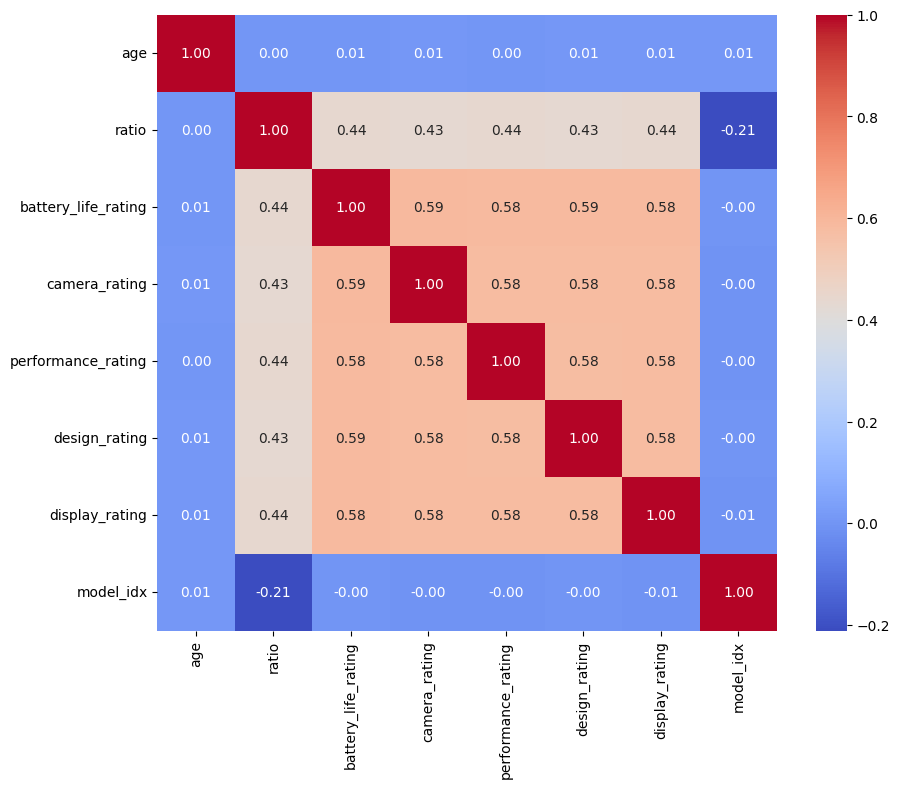

In [7]:
corr_matrix = df_clean.corr(numeric_only=True)

corr_with_target = corr_matrix["model_idx"].sort_values(ascending=False)
print(corr_with_target)


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

### Scaling

In [8]:
X = df_clean[features]
y = df_clean['model_idx']

X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(40000, 7) (10000, 7)
(40000,) (10000,)


### Rete neurale

In [17]:
tf.random.set_seed(42)

model = keras.models.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(70, activation='relu'),
    keras.layers.Dense(55, activation='relu'),
    keras.layers.Dense(44, activation='relu'),
    keras.layers.Dense(22, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.004),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 70)             │           560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 55)             │         3,905 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 44)             │         2,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 22)             │           990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,919 (30.93 KB)

 Trainable params: 7,919 (30.93 KB)

 Non-trainable params: 0 (0.00 B)

### Allenamento

In [18]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1077 - loss: 2.7492 - val_accuracy: 0.1092 - val_loss: 2.7032
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1132 - loss: 2.7138 - val_accuracy: 0.1114 - val_loss: 2.6940
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1124 - loss: 2.7076 - val_accuracy: 0.1115 - val_loss: 2.6931
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1139 - loss: 2.7032 - val_accuracy: 0.1113 - val_loss: 2.6890
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1145 - loss: 2.7009 - val_accuracy: 0.1101 - val_loss: 2.6879
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1162 - loss: 2.6982 - val_accuracy: 0.1110 - val_loss: 2.6871
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1154 - loss: 2.6968 - val_accuracy: 0.1134 - val_loss: 2.6845
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1157 - loss: 2.6947 - 

### Valutazione performance

#### Analisi del traning

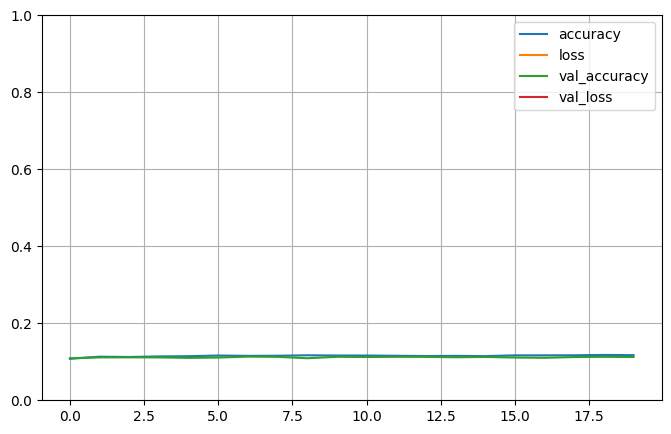

In [19]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

#### Alcune Metriche

In [20]:
y_tmp = model.predict(X_test)
y_pred = np.argmax(y_tmp, axis=1)

class_report = classification_report(y_test, y_pred, digits=4, zero_division=0)
auc = roc_auc_score(y_test, y_tmp, multi_class='ovr', average='macro')
print("ROC AUC:", auc)
print(class_report)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
ROC AUC: 0.7232302143017829
              precision    recall  f1-score   support

           0     0.1953    0.3620    0.2537       710
           1     0.0582    0.0353    0.0440       481
           2     0.0000    0.0000    0.0000       494
           3     0.0000    0.0000    0.0000       456
           4     0.1967    0.0343    0.0584       350
           5     0.0662    0.0412    0.0508       485
           6     0.1887    0.0563    0.0868       355
           7     0.0000    0.0000    0.0000       459
           8     0.0621    0.0618    0.0619       502
           9     0.0000    0.0000    0.0000       465
          10     0.1212    0.5357    0.1977       728
          11     0.0000    0.0000    0.0000       380
          12     0.0844    0.3726    0.1377       467
          13     0.0755    0.0166    0.0273       481
          14     0.0000    0.0000    0.0000       484
          15     0.1126    0.3596    0.1715       342
          16

### Conclusioni

La selezione delle feature è corretta e coerente con l’obiettivo del progetto: età e valutazioni su batteria, fotocamera, performance, design e display sono informazioni rilevanti per stimare le preferenze degli utenti.
Tuttavia il training è miseramente fallito: un’accuracy intorno al 10% indica che il modello si comporta come una scelta casuale, senza apprendere pattern utili dai dati.